In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directorios del episodio
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data" / "interim"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo general
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Directorio:", BASE_DIR)
print("Tablas:", TABLES_DIR)
print("Figuras:", FIGURES_DIR)

Directorio: c:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\008_Homogamia
Tablas: c:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\008_Homogamia\outputs\tables
Figuras: c:\Users\USUARIO\Desktop\Colombia_en_datos\episodios\008_Homogamia\outputs\figures


# cargar las parejas

In [2]:
ruta_parejas = (
    TABLES_DIR / "parejas_identificadas_medellin.csv"
)

parejas = pd.read_csv(
    ruta_parejas,
    low_memory=False
)

print("Dimensiones:", parejas.shape)
print("\nColumnas disponibles:")
print(parejas.columns.tolist())

display(parejas.head())

Dimensiones: (376683, 18)

Columnas disponibles:
['U_DPTO', 'U_MPIO', 'UA_CLASE', 'COD_ENCUESTAS', 'U_VIVIENDA', 'P_NROHOG', 'jefe_P_NRO_PER', 'jefe_P_SEXO', 'jefe_P_EDADR', 'jefe_P_PARENTESCOR', 'jefe_PA1_GRP_ETNIC', 'jefe_P_EST_CIVIL', 'pareja_P_NRO_PER', 'pareja_P_SEXO', 'pareja_P_EDADR', 'pareja_P_PARENTESCOR', 'pareja_PA1_GRP_ETNIC', 'pareja_P_EST_CIVIL']


,U_DPTO,U_MPIO,UA_CLASE,COD_ENCUESTAS,U_VIVIENDA,P_NROHOG,jefe_P_NRO_PER,jefe_P_SEXO,jefe_P_EDADR,jefe_P_PARENTESCOR,jefe_PA1_GRP_ETNIC,jefe_P_EST_CIVIL,pareja_P_NRO_PER,pareja_P_SEXO,pareja_P_EDADR,pareja_P_PARENTESCOR,pareja_PA1_GRP_ETNIC,pareja_P_EST_CIVIL
0,5,1,1,3626,4,1,2,2,11,1,6,1,5,1,11,2,6,1
1,5,1,1,3630,1,2,3,2,6,1,6,1,4,1,6,2,6,1
2,5,1,1,3632,6,1,3,2,8,1,6,2,1,1,7,2,6,2
3,5,1,1,3634,9,1,1,2,7,1,6,1,2,1,8,2,6,1
4,5,1,1,3636,10,1,1,2,5,1,6,1,3,1,6,2,6,1


## Preparar los datos

In [3]:
# Etiquetas de las categorías del DANE
categorias = {
    1: "Indígena",
    2: "Gitano/Rrom",
    3: "Raizal",
    4: "Palenquero",
    5: "Negro, mulato o afro",
    6: "Ningún grupo étnico",
    9: "No informa"
}

col_jefe = "jefe_PA1_GRP_ETNIC"
col_pareja = "pareja_PA1_GRP_ETNIC"

# Convertir los códigos a valores numéricos
parejas[col_jefe] = pd.to_numeric(
    parejas[col_jefe], errors="coerce"
)

parejas[col_pareja] = pd.to_numeric(
    parejas[col_pareja], errors="coerce"
)

# Crear etiquetas para ambas personas
parejas["categoria_jefe"] = (
    parejas[col_jefe].map(categorias)
)

parejas["categoria_pareja"] = (
    parejas[col_pareja].map(categorias)
)

# Coincidencia entre las categorías reportadas
parejas["misma_categoria"] = (
    parejas[col_jefe] == parejas[col_pareja]
)

# Para el análisis principal, considerar únicamente códigos 1 a 6
validas = parejas[
    parejas[col_jefe].between(1, 6)
    & parejas[col_pareja].between(1, 6)
].copy()

print("Parejas identificadas:", len(parejas))
print("Parejas con categorías válidas:", len(validas))
print(
    "Coincidencia observada:",
    f"{validas['misma_categoria'].mean():.2%}"
)

Parejas identificadas: 376683
Parejas con categorías válidas: 375059
Coincidencia observada: 99.00%


## Coincidencia global observada frente a esperada

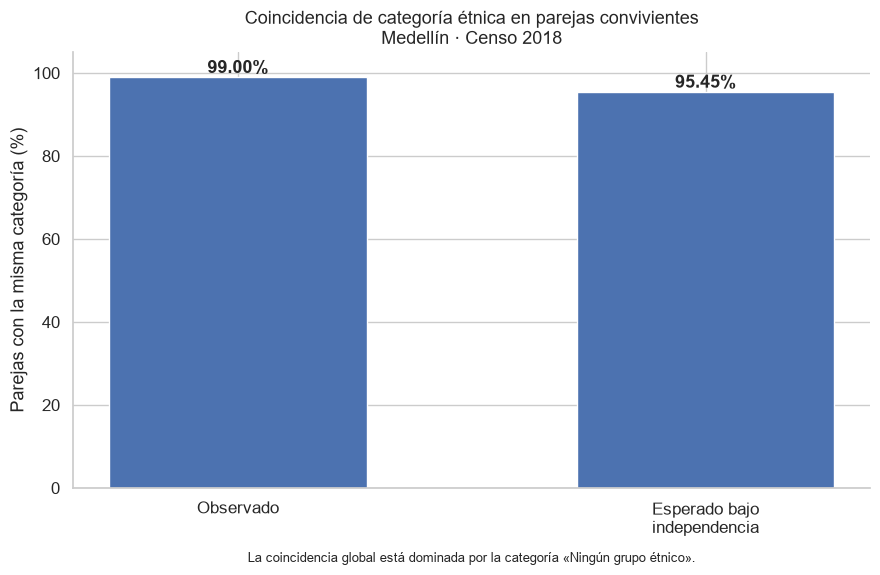

In [4]:
observado = 0.989986
esperado = 0.954532

fig, ax = plt.subplots(figsize=(9, 6))

etiquetas = ["Observado", "Esperado bajo\nindependencia"]
valores = [observado * 100, esperado * 100]

barras = ax.bar(
    etiquetas,
    valores,
    width=0.55
)

ax.set_ylim(0, 105)
ax.set_ylabel("Parejas con la misma categoría (%)")
ax.set_title(
    "Coincidencia de categoría étnica en parejas convivientes\n"
    "Medellín · Censo 2018"
)

for barra, valor in zip(barras, valores):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center",
        fontweight="bold"
    )

ax.text(
    0.5, -0.17,
    "La coincidencia global está dominada por la categoría "
    "«Ningún grupo étnico».",
    transform=ax.transAxes,
    ha="center",
    fontsize=9
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "01_coincidencia_global.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

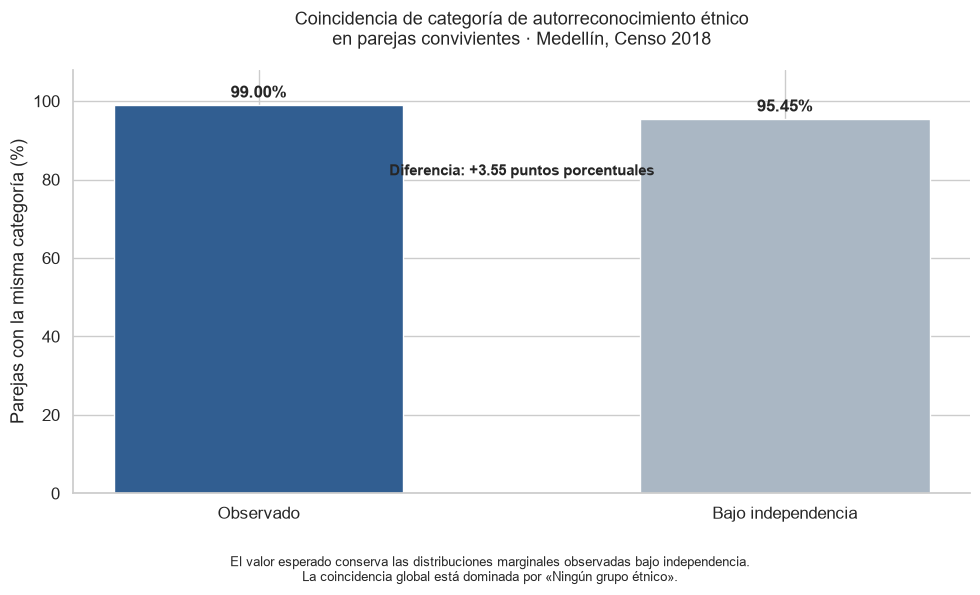

In [5]:
observado = 0.989986
esperado = 0.954532

diferencia = (observado - esperado) * 100

fig, ax = plt.subplots(figsize=(10, 6))

etiquetas = ["Observado", "Bajo independencia"]
valores = [observado * 100, esperado * 100]

colores = ["#315E91", "#AAB7C4"]

barras = ax.bar(
    etiquetas,
    valores,
    width=0.55,
    color=colores
)

ax.set_ylim(0, 108)
ax.set_ylabel("Parejas con la misma categoría (%)")

ax.set_title(
    "Coincidencia de categoría de autorreconocimiento étnico\n"
    "en parejas convivientes · Medellín, Censo 2018",
    pad=18
)

# Porcentajes sobre las barras
for barra, valor in zip(barras, valores):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12
    )

# Diferencia entre los dos porcentajes
ax.text(
    0.5,
    0.76,
    f"Diferencia: +{diferencia:.2f} puntos porcentuales",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

# Nota metodológica
fig.text(
    0.5,
    0.015,
    "El valor esperado conserva las distribuciones marginales "
    "observadas bajo independencia.\n"
    "La coincidencia global está dominada por «Ningún grupo étnico».",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    FIGURES_DIR / "01_coincidencia_global.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Coincidencia por categoría

In [6]:
# Resumen por categoría reportada por la jefatura
resumen_categoria = (
    validas
    .groupby("categoria_jefe", observed=True)
    .agg(
        total_parejas=("misma_categoria", "size"),
        parejas_misma_categoria=("misma_categoria", "sum"),
        porcentaje_coincidencia=("misma_categoria", "mean")
    )
    .reset_index()
)

# Ordenar de mayor a menor porcentaje
resumen_categoria = resumen_categoria.sort_values(
    "porcentaje_coincidencia",
    ascending=True
)

# Mostrar resultados
resumen_categoria["porcentaje_coincidencia"] *= 100

display(
    resumen_categoria[
        [
            "categoria_jefe",
            "total_parejas",
            "parejas_misma_categoria",
            "porcentaje_coincidencia"
        ]
    ].round({"porcentaje_coincidencia": 2})
)

,categoria_jefe,total_parejas,parejas_misma_categoria,porcentaje_coincidencia
0,Gitano/Rrom,7,1,14.29
4,Palenquero,17,4,23.53
1,Indígena,366,161,43.99
5,Raizal,43,19,44.19
2,"Negro, mulato o afro",8727,6634,76.02
3,Ningún grupo étnico,365899,364484,99.61


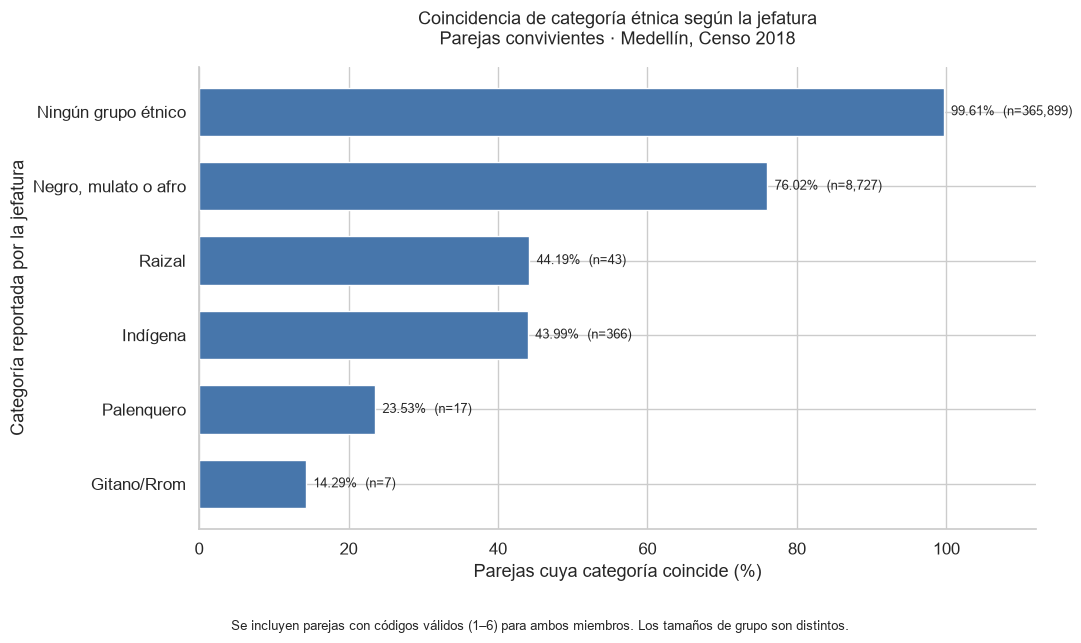

In [7]:
fig, ax = plt.subplots(figsize=(11, 6.5))

barras = ax.barh(
    resumen_categoria["categoria_jefe"],
    resumen_categoria["porcentaje_coincidencia"],
    color="#4776AB",
    height=0.65
)

ax.set_xlim(0, 112)
ax.set_xlabel("Parejas cuya categoría coincide (%)")
ax.set_ylabel("Categoría reportada por la jefatura")

ax.set_title(
    "Coincidencia de categoría étnica según la jefatura\n"
    "Parejas convivientes · Medellín, Censo 2018",
    pad=16
)

# Porcentaje y número de parejas al final de cada barra
for barra, (_, fila) in zip(barras, resumen_categoria.iterrows()):
    porcentaje = fila["porcentaje_coincidencia"]
    n = int(fila["total_parejas"])

    ax.text(
        porcentaje + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{porcentaje:.2f}%  (n={n:,})",
        va="center",
        fontsize=9
    )

fig.text(
    0.5,
    0.015,
    "Se incluyen parejas con códigos válidos (1–6) para ambos miembros. "
    "Los tamaños de grupo son distintos.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(
    FIGURES_DIR / "02_coincidencia_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Preparar los datos de la categoría afro

In [8]:
# Jefaturas que reportaron la categoría afro (código 5)
parejas_afro = validas[
    validas["jefe_PA1_GRP_ETNIC"] == 5
].copy()

total_afro = len(parejas_afro)
coinciden_afro = parejas_afro["misma_categoria"].sum()
difieren_afro = total_afro - coinciden_afro

porcentaje_coinciden = coinciden_afro / total_afro * 100
porcentaje_difieren = difieren_afro / total_afro * 100

print(f"Total de parejas: {total_afro:,}")
print(f"Misma categoría: {coinciden_afro:,} ({porcentaje_coinciden:.2f}%)")
print(f"Categoría diferente: {difieren_afro:,} ({porcentaje_difieren:.2f}%)")

Total de parejas: 8,727
Misma categoría: 6,634 (76.02%)
Categoría diferente: 2,093 (23.98%)


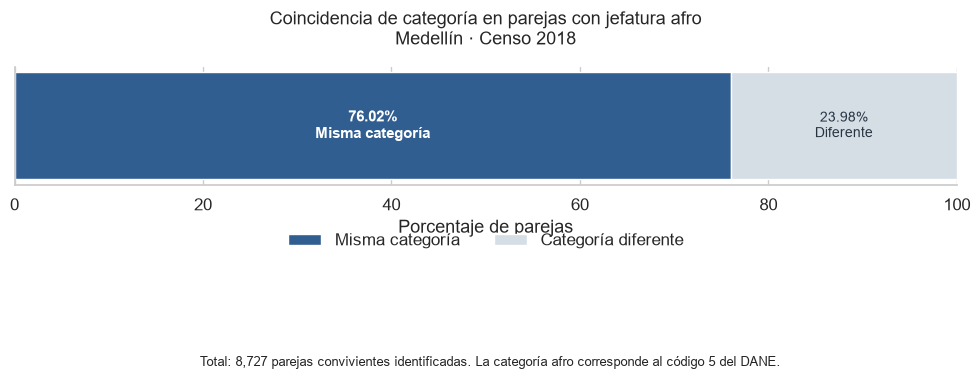

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))

# Una barra que representa el 100% de las parejas
ax.barh(
    ["Jefatura categoría afro"],
    [porcentaje_coinciden],
    color="#315E91",
    height=0.48,
    label="Misma categoría"
)

ax.barh(
    ["Jefatura categoría afro"],
    [porcentaje_difieren],
    left=[porcentaje_coinciden],
    color="#D5DDE5",
    height=0.48,
    label="Categoría diferente"
)

# Etiquetas dentro de cada segmento
ax.text(
    porcentaje_coinciden / 2,
    0,
    f"{porcentaje_coinciden:.2f}%\nMisma categoría",
    ha="center",
    va="center",
    color="white",
    fontweight="bold",
    fontsize=11
)

ax.text(
    porcentaje_coinciden + porcentaje_difieren / 2,
    0,
    f"{porcentaje_difieren:.2f}%\nDiferente",
    ha="center",
    va="center",
    color="#263442",
    fontsize=10
)

ax.set_xlim(0, 100)
ax.set_xlabel("Porcentaje de parejas")
ax.set_yticks([])
ax.set_title(
    "Coincidencia de categoría en parejas con jefatura afro\n"
    "Medellín · Censo 2018",
    pad=16
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=False
)

fig.text(
    0.5,
    0.01,
    f"Total: {total_afro:,} parejas convivientes identificadas. "
    "La categoría afro corresponde al código 5 del DANE.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.12, 1, 1])

fig.savefig(
    FIGURES_DIR / "03_coincidencia_jefatura_afro.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Preparar la matriz
porcentajes por fila. Así, cada fila representa el 100% de las parejas de una categoría de jefatura.

In [10]:
# Tabla de contingencia: jefatura × pareja
matriz_conteos = pd.crosstab(
    validas["categoria_jefe"],
    validas["categoria_pareja"]
)

# Orden de las categorías
orden = [
    "Indígena",
    "Gitano/Rrom",
    "Raizal",
    "Palenquero",
    "Negro, mulato o afro",
    "Ningún grupo étnico"
]

matriz_conteos = matriz_conteos.reindex(
    index=orden,
    columns=orden,
    fill_value=0
)

# Porcentaje dentro de cada categoría de jefatura
matriz_pct = matriz_conteos.div(
    matriz_conteos.sum(axis=1),
    axis=0
) * 100

# Tamaño de cada grupo para mostrarlo en las etiquetas
n_por_categoria = matriz_conteos.sum(axis=1)

matriz_pct.index = [
    f"{categoria} (n={n_por_categoria[categoria]:,})"
    for categoria in orden
]

display(matriz_pct.round(2))

categoria_pareja,Indígena,Gitano/Rrom,Raizal,Palenquero,"Negro, mulato o afro",Ningún grupo étnico
Indígena (n=366),43.99,0.55,0.00,0.00,4.64,50.82
Gitano/Rrom (n=7),0.00,14.29,0.00,0.00,14.29,71.43
Raizal (n=43),0.00,0.00,44.19,0.00,6.98,48.84
Palenquero (n=17),0.00,0.00,0.00,23.53,29.41,47.06
"Negro, mulato o afro (n=8,727)",0.15,0.01,0.03,0.01,76.02,23.78
"Ningún grupo étnico (n=365,899)",0.04,0.00,0.00,0.00,0.35,99.61


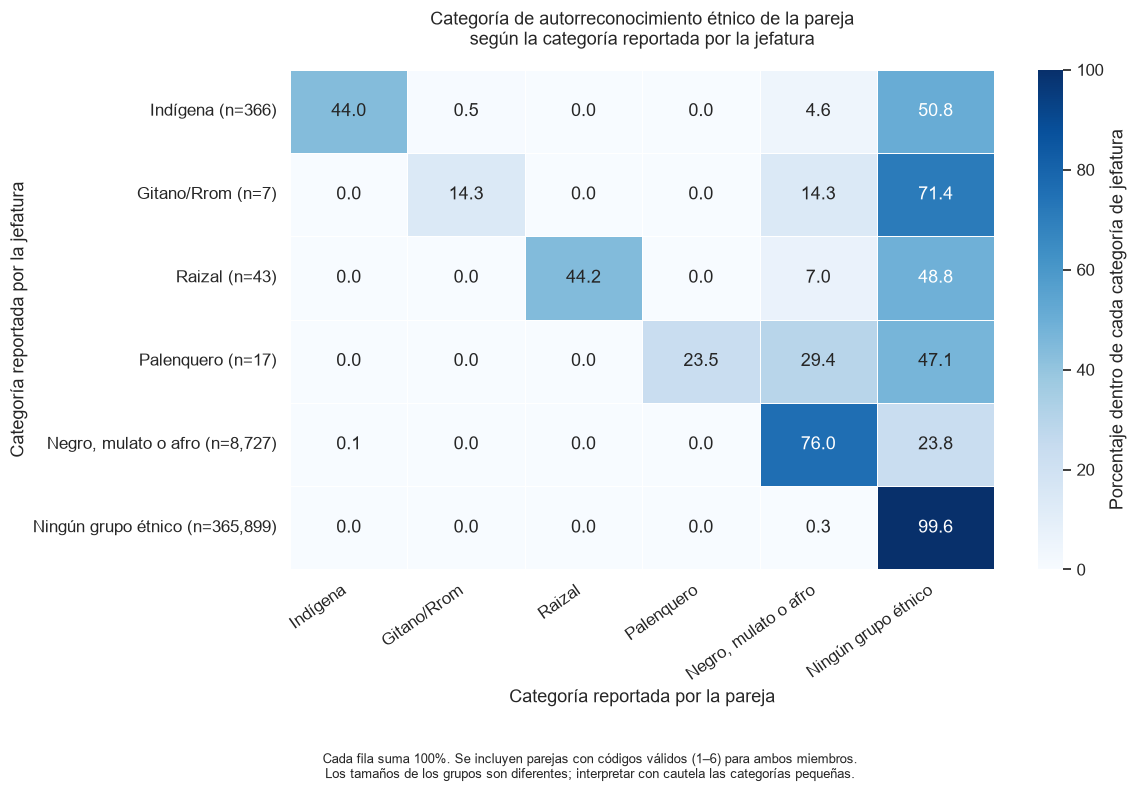

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    matriz_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Porcentaje dentro de cada categoría de jefatura"
    },
    ax=ax
)

ax.set_title(
    "Categoría de autorreconocimiento étnico de la pareja\n"
    "según la categoría reportada por la jefatura",
    pad=18
)

ax.set_xlabel("Categoría reportada por la pareja")
ax.set_ylabel("Categoría reportada por la jefatura")

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

fig.text(
    0.5,
    0.015,
    "Cada fila suma 100%. Se incluyen parejas con códigos válidos (1–6) "
    "para ambos miembros.\n"
    "Los tamaños de los grupos son diferentes; interpretar con cautela "
    "las categorías pequeñas.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    FIGURES_DIR / "04_matriz_coincidencia_etnica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
parejas[["jefe_P_SEXO", "pareja_P_SEXO"]].value_counts().sort_index()

jefe_P_SEXO  pareja_P_SEXO
1            1                  1738
             2                267543
2            1                105358
             2                  2044
Name: count, dtype: int64

In [13]:
pd.crosstab(
    parejas["jefe_P_SEXO"],
    parejas["pareja_P_SEXO"]
)

pareja_P_SEXO,1,2
jefe_P_SEXO,,
1,1738,267543
2,105358,2044


In [14]:
pd.crosstab(
    [parejas["jefe_P_SEXO"], parejas["jefe_PA1_GRP_ETNIC"]],
    [parejas["pareja_P_SEXO"], parejas["pareja_PA1_GRP_ETNIC"]]
)

pareja_P_SEXO                    1                                2            \
pareja_PA1_GRP_ETNIC             1  2  3  4     5       6    9    1  2   3  4   
jefe_P_SEXO jefe_PA1_GRP_ETNIC                                                  
1           1                    1  0  0  0     0       1    0  118  2   0  0   
            2                    0  0  0  0     0       0    0    0  1   0  0   
            3                    0  0  0  0     0       1    0    0  0  11  0   
            4                    0  0  0  0     0       0    0    0  0   0  3   
            5                    1  0  0  0    43      11    1    9  1   2  0   
            6                    2  0  0  0     9    1550   23   96  1   9  1   
            9                    0  0  0  0     3      12   80    3  0   0  0   
2           1                   39  0  0  0     9      46    0    3  0   0  0   
            2                    0  0  0  0     0       1    0    0  0   0  0   
            3                    0  0  8  0     0       8    0    0  0   0  0   
            4                    0  0  0  1     3       3    0    0  0   0  0   
            5                    3  0  1  1  2156     522    4    0  0   0  0   
            6                   32  1  8  0   501  101628   94    0  0   0  0   
            9                    0  0  0  0     8      99  182    0  0   0  0   

pareja_P_SEXO                                      
pareja_PA1_GRP_ETNIC               5       6    9  
jefe_P_SEXO jefe_PA1_GRP_ETNIC                     
1           1                      8     137    1  
            2                      1       4    0  
            3                      3      12    0  
            4                      2       5    0  
            5                   4388    1521    8  
            6                    745  259478  185  
            9                     20     326  442  
2           1                      0       2    0  
            2                      0       0    0  
            3                      0       0    0  
            4                      0       0    0  
            5                     47      21    1  
            6                     10    1828   25  
            9                      1      27   79

In [15]:
# ============================================================
# ANÁLISIS DE HOMOGAMIA ÉTNICA POR SEXO
# Categoría 5 = Negro/mulato/afrodescendiente/afrocolombiano
# ============================================================

# Creamos una copia para trabajar
df = parejas.copy()

# ------------------------------------------------------------
# 1. Identificar la categoría étnica de cada sexo
# ------------------------------------------------------------

# Sexo 1 = hombre
# Sexo 2 = mujer

df["hombre_etnia"] = np.where(
    df["jefe_P_SEXO"] == 1,
    df["jefe_PA1_GRP_ETNIC"],
    df["pareja_PA1_GRP_ETNIC"]
)

df["mujer_etnia"] = np.where(
    df["jefe_P_SEXO"] == 2,
    df["jefe_PA1_GRP_ETNIC"],
    df["pareja_PA1_GRP_ETNIC"]
)

# ------------------------------------------------------------
# 2. Parejas hombre-mujer
# ------------------------------------------------------------

parejas_hm = df[
    (
        ((df["jefe_P_SEXO"] == 1) & (df["pareja_P_SEXO"] == 2)) |
        ((df["jefe_P_SEXO"] == 2) & (df["pareja_P_SEXO"] == 1))
    )
].copy()

len(parejas_hm)

372901

In [16]:
# ------------------------------------------------------------
# 3. Hombres categoría 5
# ------------------------------------------------------------

hombres_5 = parejas_hm[
    parejas_hm["hombre_etnia"] == 5
].copy()

hombres_5["misma_etnia"] = (
    hombres_5["mujer_etnia"] == 5
)

# ------------------------------------------------------------
# 4. Mujeres categoría 5
# ------------------------------------------------------------

mujeres_5 = parejas_hm[
    parejas_hm["mujer_etnia"] == 5
].copy()

mujeres_5["misma_etnia"] = (
    mujeres_5["hombre_etnia"] == 5
)

# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

resultado = pd.DataFrame({
    "grupo": [
        "Hombres categoría 5",
        "Mujeres categoría 5"
    ],
    "misma_categoria_5": [
        hombres_5["misma_etnia"].sum(),
        mujeres_5["misma_etnia"].sum()
    ],
    "total": [
        len(hombres_5),
        len(mujeres_5)
    ]
})

resultado["otra_categoria"] = (
    resultado["total"] - resultado["misma_categoria_5"]
)

resultado["porcentaje_misma_categoria"] = (
    resultado["misma_categoria_5"] /
    resultado["total"] * 100
)

resultado

,grupo,misma_categoria_5,total,otra_categoria,porcentaje_misma_categoria
0,Hombres categoría 5,6544,8606,2062,76.039972
1,Mujeres categoría 5,6544,7854,1310,83.320601


In [17]:
# ============================================================
# PAREJAS DEL MISMO SEXO
# ============================================================

# Hombre-hombre
parejas_hh = df[
    (df["jefe_P_SEXO"] == 1) &
    (df["pareja_P_SEXO"] == 1)
].copy()

# Mujer-mujer
parejas_mm = df[
    (df["jefe_P_SEXO"] == 2) &
    (df["pareja_P_SEXO"] == 2)
].copy()

# ------------------------------------------------------------
# Hombres categoría 5 dentro de parejas hombre-hombre
# ------------------------------------------------------------

hh_5 = parejas_hh[
    parejas_hh["jefe_PA1_GRP_ETNIC"] == 5
].copy()

hh_5["misma_etnia"] = (
    hh_5["pareja_PA1_GRP_ETNIC"] == 5
)

# ------------------------------------------------------------
# Mujeres categoría 5 dentro de parejas mujer-mujer
# ------------------------------------------------------------

mm_5 = parejas_mm[
    parejas_mm["jefe_PA1_GRP_ETNIC"] == 5
].copy()

mm_5["misma_etnia"] = (
    mm_5["pareja_PA1_GRP_ETNIC"] == 5
)

# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

resultado_mismo_sexo = pd.DataFrame({
    "tipo_pareja": [
        "Hombre-hombre",
        "Mujer-mujer"
    ],
    "misma_categoria_5": [
        hh_5["misma_etnia"].sum(),
        mm_5["misma_etnia"].sum()
    ],
    "total_personas_categoria_5": [
        len(hh_5),
        len(mm_5)
    ]
})

resultado_mismo_sexo["otra_categoria"] = (
    resultado_mismo_sexo["total_personas_categoria_5"]
    - resultado_mismo_sexo["misma_categoria_5"]
)

resultado_mismo_sexo["porcentaje_misma_categoria"] = (
    resultado_mismo_sexo["misma_categoria_5"]
    / resultado_mismo_sexo["total_personas_categoria_5"]
    * 100
)

resultado_mismo_sexo

,tipo_pareja,misma_categoria_5,total_personas_categoria_5,otra_categoria,porcentaje_misma_categoria
0,Hombre-hombre,43,56,13,76.785714
1,Mujer-mujer,47,69,22,68.115942


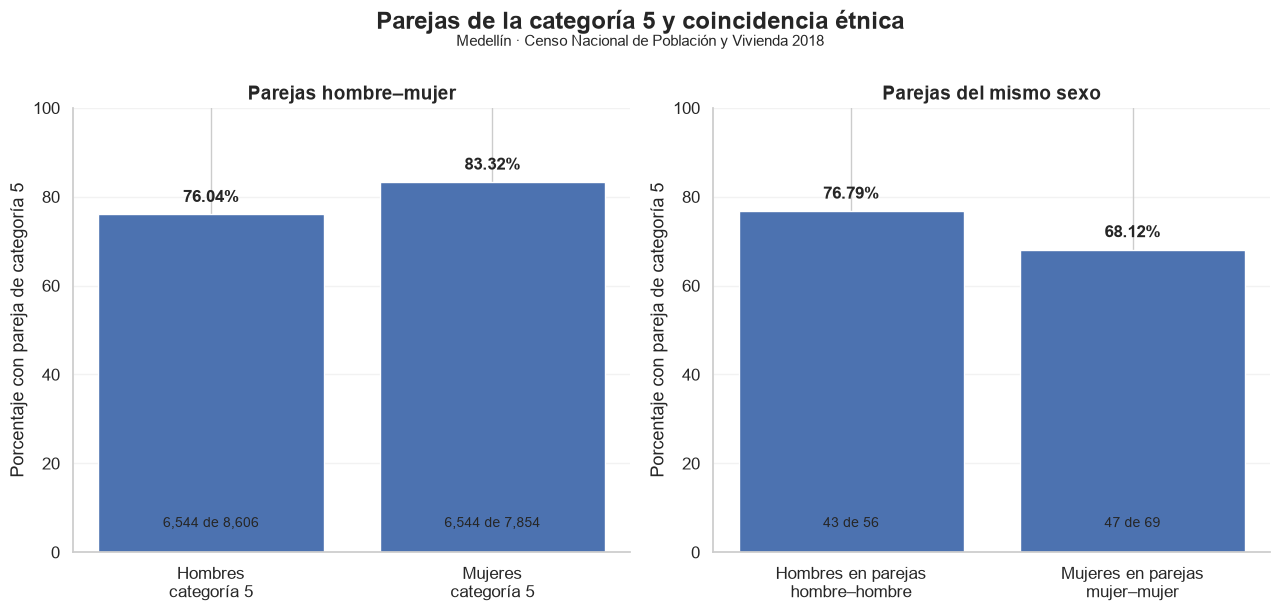

In [18]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICA: HOMOGAMIA ÉTNICA POR TIPO DE PAREJA
# Categoría 5 = Negro, mulato, afrodescendiente o afrocolombiano
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ------------------------------------------------------------
# 1. Parejas hombre-mujer
# ------------------------------------------------------------

datos_hm = resultado.copy()

labels_hm = [
    "Hombres\ncategoría 5",
    "Mujeres\ncategoría 5"
]

valores_hm = datos_hm["porcentaje_misma_categoria"].values

barras_hm = axes[0].bar(
    labels_hm,
    valores_hm
)

axes[0].set_title(
    "Parejas hombre–mujer",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_ylabel("Porcentaje con pareja de categoría 5")
axes[0].set_ylim(0, 100)
axes[0].grid(
    axis="y",
    alpha=0.25
)

# Etiquetas de porcentaje y conteo
for barra, porcentaje, misma, total in zip(
    barras_hm,
    datos_hm["porcentaje_misma_categoria"],
    datos_hm["misma_categoria_5"],
    datos_hm["total"]
):
    axes[0].text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    axes[0].text(
        barra.get_x() + barra.get_width() / 2,
        5,
        f"{misma:,} de {total:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )


# ------------------------------------------------------------
# 2. Parejas del mismo sexo
# ------------------------------------------------------------

datos_ms = resultado_mismo_sexo.copy()

labels_ms = [
    "Hombres en parejas\nhombre–hombre",
    "Mujeres en parejas\nmujer–mujer"
]

valores_ms = datos_ms["porcentaje_misma_categoria"].values

barras_ms = axes[1].bar(
    labels_ms,
    valores_ms
)

axes[1].set_title(
    "Parejas del mismo sexo",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_ylabel("Porcentaje con pareja de categoría 5")
axes[1].set_ylim(0, 100)
axes[1].grid(
    axis="y",
    alpha=0.25
)

# Etiquetas de porcentaje y conteo
for barra, porcentaje, misma, total in zip(
    barras_ms,
    datos_ms["porcentaje_misma_categoria"],
    datos_ms["misma_categoria_5"],
    datos_ms["total_personas_categoria_5"]
):
    axes[1].text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    axes[1].text(
        barra.get_x() + barra.get_width() / 2,
        5,
        f"{misma:,} de {total:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )


# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

fig.suptitle(
    "Parejas de la categoría 5 y coincidencia étnica",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.96,
    "Medellín · Censo Nacional de Población y Vivienda 2018",
    ha="center",
    fontsize=11
)

plt.tight_layout()

plt.show()